In [1]:
import matplotlib.pyplot as plt 
import pandas as pd 

We have a `matplotlib-inline` package, so we don't have to do anything. Otherwise if the plots are not showing, run the following magic command: 

```%matplotlib inline```

## `plt.subplots`

The easiest way to start: use `plt.subplots()` to initalize both figure and a single axes: 

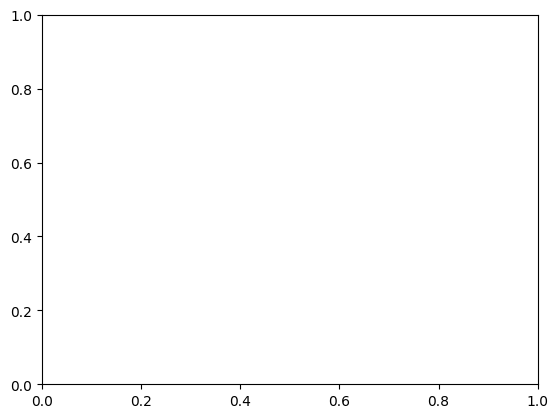

In [14]:
f, ax = plt.subplots()

What is f, ax?

In [13]:
type(f)

matplotlib.figure.Figure

In [15]:
type(ax)

matplotlib.axes._axes.Axes

We can inspect the tree-like structure of the figure object: 

In [16]:
f.get_children()

[<matplotlib.patches.Rectangle at 0x28c6c8f7b50>, <Axes: >]

In [17]:
ax.get_children()

 Text(0.5, 1.0, ''),
 Text(0.0, 1.0, ''),
 Text(1.0, 1.0, ''),

You will see that once we plot something, there will be additional elements here! 

We can customize the figure size: 

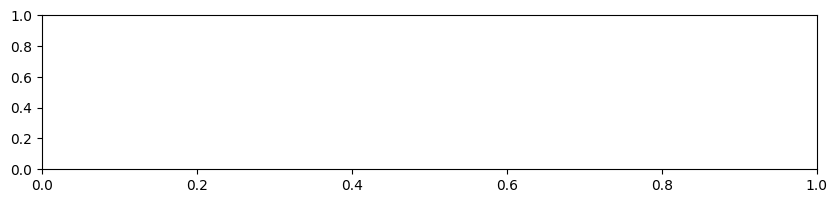

In [4]:
f, ax = plt.subplots(figsize=(10,2))

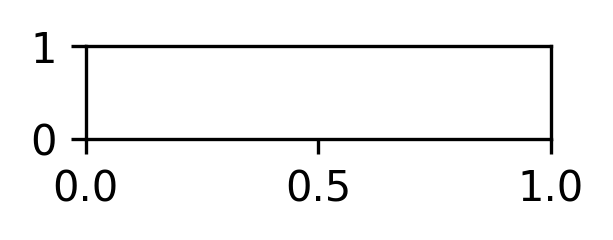

In [76]:
f, ax = plt.subplots(figsize=(2,0.4), dpi=300)

We can use the same function to create a grid of axes: 

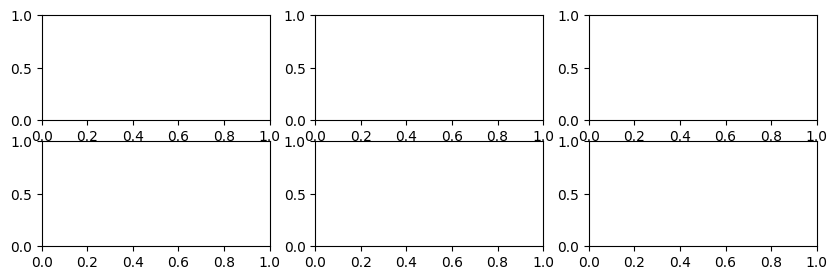

In [72]:
f, ax = plt.subplots(figsize = (10,3), 
                     ncols = 3, nrows = 2, 
                     # gridspec_kw = {'wspace': 0.4},
                     # gridspec_kw = {'wspace': 0.4, 'width_ratios':[1,2,1]},
                     # layout = 'constrained', 
                     # sharex = True
                    )

Watch out! `ax` is no longer a single axes object: 

In [20]:
type(ax)

numpy.ndarray

In [21]:
ax

array([[<Axes: >, <Axes: >, <Axes: >],
       [<Axes: >, <Axes: >, <Axes: >]], dtype=object)

In [22]:
type(ax[0,1])

matplotlib.axes._axes.Axes

If we want that subplots always creates an array of axes (useful e.g. when we want to create a function which works the same no matter the # of axes), we can use another parameter: `squeeze=False`

numpy.ndarray

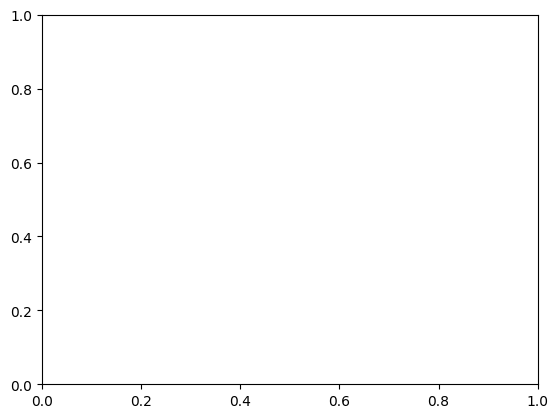

In [23]:
f, ax = plt.subplots(squeeze=False)
type(ax)

## `plt.subplot_mosaic`

Another function: `subplot_mosaic`

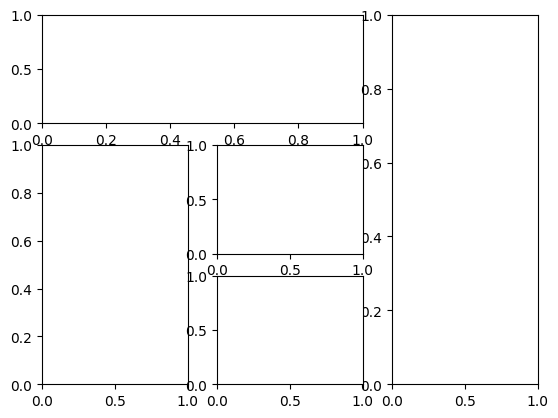

In [38]:
f, ax = plt.subplot_mosaic(
    mosaic = [ ['a', 'a', 'b'], 
               ['c', 'd', 'b'], 
               ['c', 'e', 'b'] 
             ]
              )

In [39]:
ax

{'a': <Axes: label='a'>,
 'b': <Axes: label='b'>,
 'c': <Axes: label='c'>,
 'd': <Axes: label='d'>,
 'e': <Axes: label='e'>}

We can plot things in a particular axes by addressing them using the key which we defined above: `ax['a'].plot(...)`

## Add a subplot 

Method 1: `f.add_axes`

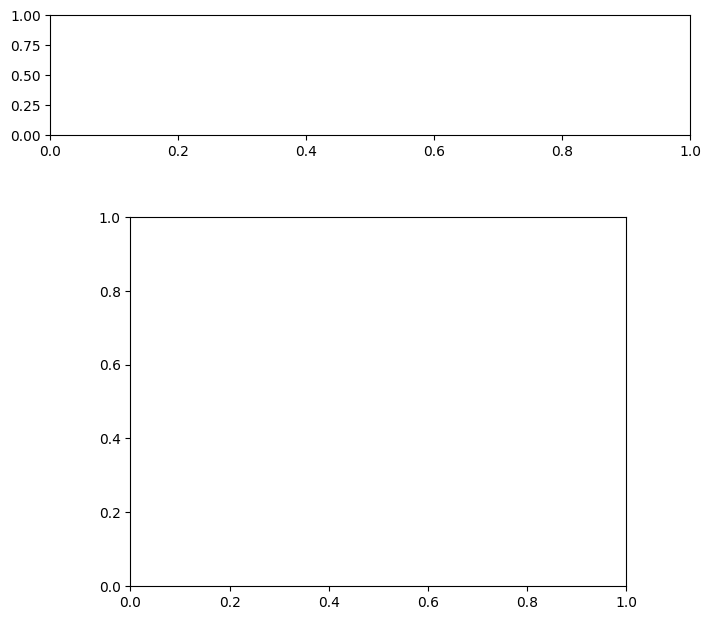

In [50]:
f, ax = plt.subplots()
ax_above = f.add_axes([0, 1.05, 1, 0.25]) # [left_x0, bottom_y0, width, height] 

In [51]:
f.get_children()

[<matplotlib.patches.Rectangle at 0x28c6c6c9b10>, <Axes: >, <Axes: >]

Method 2: `ax.inset_axes`

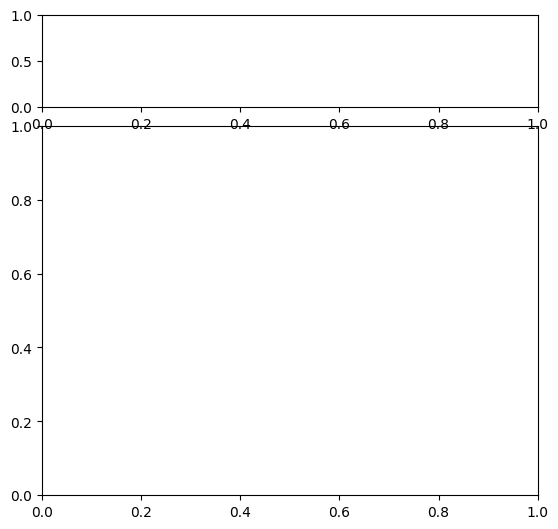

In [47]:
f, ax = plt.subplots()
ax_above = ax.inset_axes([0, 1.05, 1, 0.25]) # # [left_x0, bottom_y0, width, height] 

In [48]:
f.get_children()

[<matplotlib.patches.Rectangle at 0x28c6d0e9b10>, <Axes: >]

In [49]:
ax.get_children()

 Text(0.5, 1.0, ''),
 Text(0.0, 1.0, ''),
 Text(1.0, 1.0, ''),
 <Axes: label='inset_axes'>,

## Hide axes 

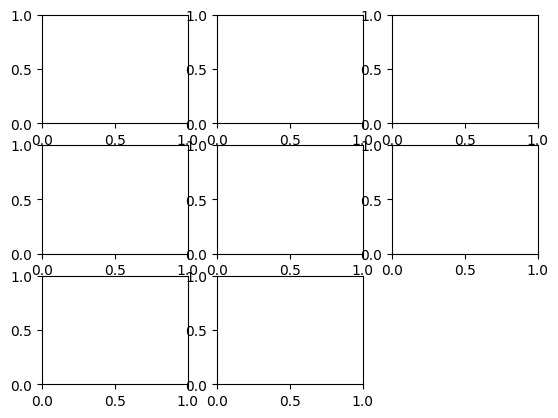

In [42]:
f, ax = plt.subplots(nrows = 3, ncols = 3)

ax[2,2].set_visible(False)

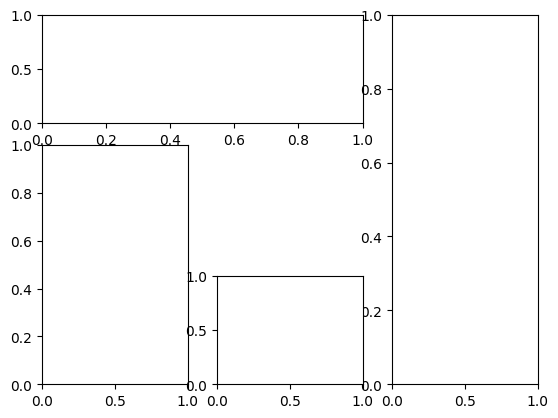

In [52]:
f, ax = plt.subplot_mosaic(
    mosaic = [ ['a', 'a', 'b'], 
               ['c', '.', 'b'], 
               ['c', 'e', 'b'] 
             ]
              )

## Projection 

If you need a polar plot or another plot with a different projection, you have to set the projection when creating the axes: 

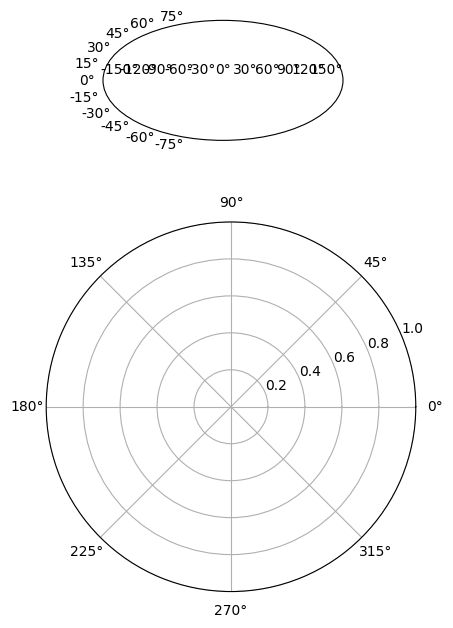

In [59]:
f, ax = plt.subplots(subplot_kw = {'projection':'polar'})
ax_above = f.add_axes([0, 1.05, 1, 0.25], projection='hammer') # [left_x0, bottom_y0, width, height] 

## Avoiding PLT 

In [61]:
from matplotlib.pyplot import Figure 

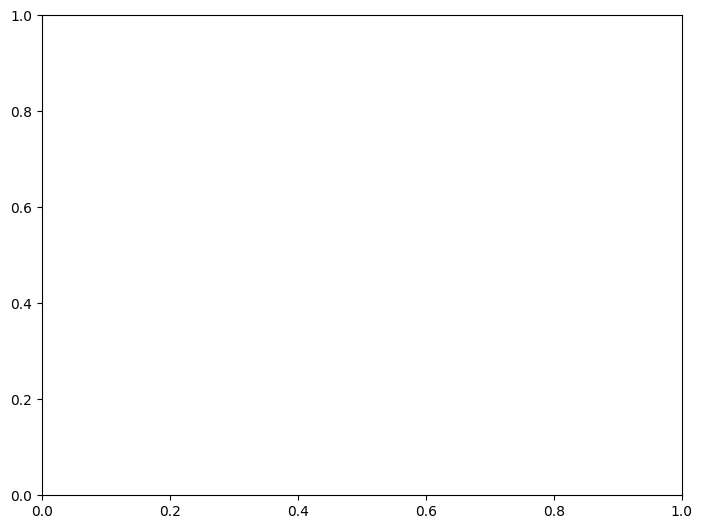

In [65]:
f = Figure()
ax = f.add_axes([0,0,1,1]) #[left_x0, bottom_y0, width, height] 
f

## Further reading 

MPL docs: https://matplotlib.org/stable/users/explain/axes/index.html